# BAMBOO on charged / polar molecular dimers — why the charge-equilibrium term matters

BAMBOO (`xnns.hybrid.models.bamboo.BAMBOO`, Gong *et al.* 2024) splits the atomic
energy into a **semi-local** neural-network term (a graph equivariant
transformer within a 5 Å cutoff) and a **charge-equilibrium electrostatic**
term built from predicted partial charges and summed over *all* pairs. On
molecular dimers held apart by more than the cutoff, the semi-local term is
blind to the other monomer — only the all-pairs electrostatics can bind them.

We reproduce the spirit of the LES long-range experiment (the same charged /
polar bio-fragment dimers), but here the long-range physics is **intrinsic to
BAMBOO**: we simply toggle `use_electrostatics` and show the electrostatic model
extrapolates the binding curves that the short-range-only variant cannot.

> **Fidelity vs. training.** The block-by-block fidelity notebook
> (`examples/fidelity_checks/bamboo_verification.ipynb`) proves the
> *implementation* matches `bytedance/bamboo` to machine precision. This
> notebook is about what the *architecture* buys you.


## 0. Setup

In [1]:
import logging, warnings
logging.disable(logging.WARNING); warnings.filterwarnings("ignore")
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io
torch.set_default_dtype(torch.float32); torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
import xnns
print("xnns", xnns.__version__, "| device:", DEVICE)

xnns 0.1.0 | device: cuda


## 1. The three dimer classes and the train/test split

Each dimer's total energy and forces are DFT references; we train on the
*binding* energy (total minus the two isolated-monomer references), which has
the same forces and removes the huge atomic baseline. We fit the **10 closest**
separations and test on the **3 farthest** (pure extrapolation, well beyond the
5 Å cutoff) — the protocol of the long-range paper.

In [2]:
from xnns.common.data import AtomicDataset, collate, load_dataset
from torch.utils.data import DataLoader

raw = load_dataset("lode_dimers", subset="bio_scan", split="all", return_info=True)
CLASSES = ["CC", "CP", "PP"]

def to_struct(d):
    info = d["info"]
    e_bind = float(d["energy"] - info["energyA"] - info["energyB"])
    return {"pos": d["pos"], "atomic_numbers": d["atomic_numbers"].tolist(),
            "energy": e_bind, "forces": d["forces"],
            "distance": float(info["distance"]), "label": info["label"]}

data = {cl: sorted([to_struct(d) for d in raw if d["info"]["label"] == cl],
                   key=lambda s: s["distance"]) for cl in CLASSES}
splits = {cl: (data[cl][:10], data[cl][10:]) for cl in CLASSES}
for cl in CLASSES:
    print(f"{cl}: {len(data[cl])} frames, separations "
          f"{data[cl][0]['distance']:.1f}-{data[cl][-1]['distance']:.1f} Å")

lode_dimers:bio_scan:   0%|          | 0/39 [00:00<?, ? struct/s]

CC: 13 frames, separations 5.6-15.0 Å
CP: 13 frames, separations 5.3-15.0 Å
PP: 13 frames, separations 5.2-15.0 Å


### The reference binding curves — CC has the deepest Coulomb tail, PP the weakest

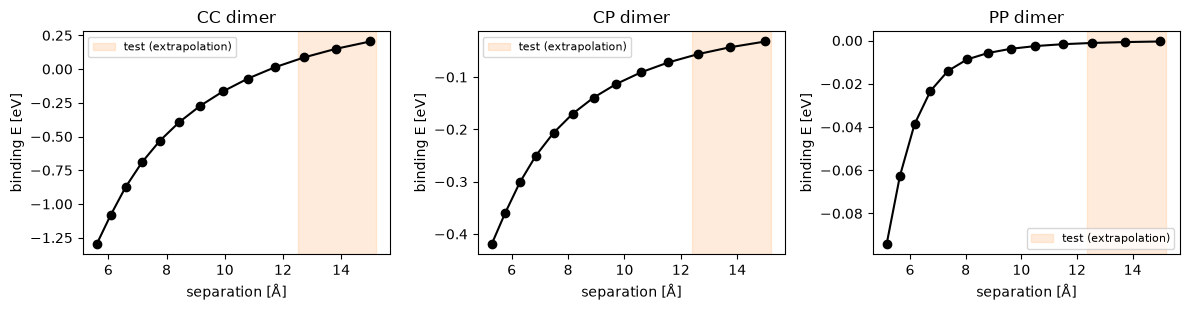

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for a, cl in zip(ax, CLASSES):
    d = [s["distance"] for s in data[cl]]; e = [s["e_bind"] if False else s["energy"] for s in data[cl]]
    a.plot(d, e, "o-", color="k")
    a.axvspan(data[cl][10]["distance"] - 0.2, data[cl][-1]["distance"] + 0.2,
              color="tab:orange", alpha=0.15, label="test (extrapolation)")
    a.set_title(f"{cl} dimer"); a.set_xlabel("separation [Å]"); a.set_ylabel("binding E [eV]")
    a.legend(fontsize=8)
plt.tight_layout(); plt.savefig("dimer_reference_curves.png", dpi=110); plt.show()

## 2. Two BAMBOO models — identical, except the electrostatic term

A small BAMBOO (feature width 32, 4 heads, 2 GET layers). The only difference
is `use_electrostatics`: the **LR** model keeps the charge-equilibrium term, the
**SR** model drops it (pure semi-local GET).

In [4]:
from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput

def make(use_elec):
    cfg = from_dict({"model": {"name": "bamboo", "cutoff": 5.0, "n_features": 32,
        "n_rbf": 16, "n_interactions": 2,
        "extra": {"num_heads": 4, "use_electrostatics": use_elec}}})
    return ForceStressOutput(build_model(cfg.model)).to(DEVICE)

## 3. Train both, per class — same data, loss, optimiser, schedule

BAMBOO's charge head starts near zero (a `tanh` around 0); like the reference
long-range fits it needs **warm restarts** to escape before a low-lr polish.
The loss weights energy heavily (the binding curve) alongside forces.

In [5]:
def run_stage(m, loader, epochs, lr0, step, ew, fw):
    opt = torch.optim.Adam(m.parameters(), lr=lr0, amsgrad=True)
    sch = torch.optim.lr_scheduler.StepLR(opt, step, 0.9)
    for _ in range(epochs):
        for b in loader:
            b = b.to(DEVICE); out = m(b)
            loss = ew * ((out["energy"] - b.energy) ** 2).mean() + \
                   fw * ((out["forces"] - b.forces) ** 2).mean()
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 10.0); opt.step()
        sch.step()

def train(m, tr):
    loader = DataLoader(AtomicDataset(tr, 5.0), batch_size=10, shuffle=True,
                        collate_fn=collate)
    for _ in range(6):
        run_stage(m, loader, 150, 1e-2, 10, 100, 1000)   # warm restarts
    run_stage(m, loader, 400, 1e-3, 40, 100, 1000)       # polish

models = {}
t0 = time.time()
for cl in CLASSES:
    tr, _ = splits[cl]
    for kind, use in [("LR", True), ("SR", False)]:
        torch.manual_seed(0)
        m = make(use); train(m, tr); models[(cl, kind)] = m
print(f"trained 6 models in {time.time() - t0:.0f}s")

trained 6 models in 162s


## 4. Binding curves + force parity (the payoff)

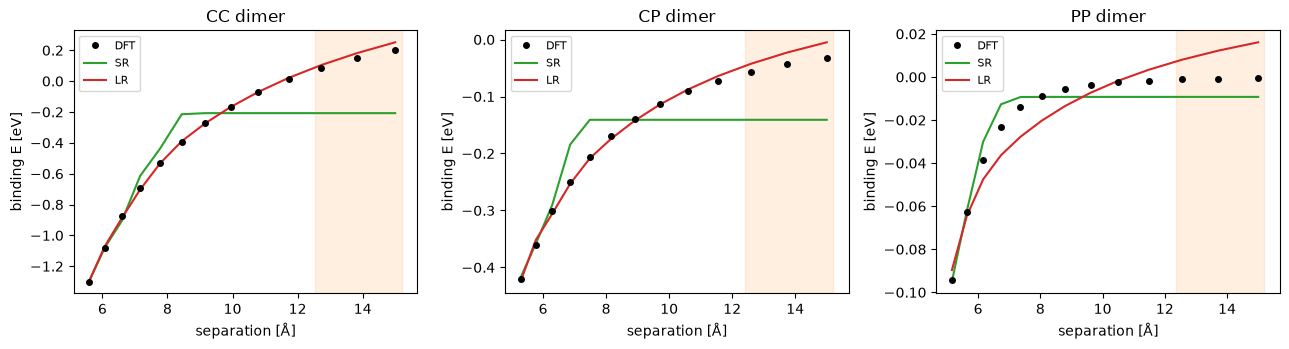

In [6]:
def bind_curve(m, S):
    m.eval(); ds = AtomicDataset(S, 5.0)
    d = np.array([s["distance"] for s in S])
    p = np.array([float(m(ds[i].to(DEVICE))["energy"].detach()) for i in range(len(S))])
    return d, p

def force_rmse(m, S):
    m.eval(); ds = AtomicDataset(S, 5.0)
    diffs = [((m(ds[i].to(DEVICE))["forces"].detach().cpu() -
               torch.tensor(S[i]["forces"], dtype=torch.float32)) ** 2)
             for i in range(len(S))]
    return float(torch.cat(diffs).mean().sqrt()) * 1000

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
results = {}
for j, cl in enumerate(CLASSES):
    tr, te = splits[cl]; a = ax[j]
    a.plot([s["distance"] for s in data[cl]], [s["energy"] for s in data[cl]],
           "o", color="k", label="DFT", zorder=5, ms=4)
    for kind, col in [("SR", "tab:green"), ("LR", "tab:red")]:
        d, p = bind_curve(models[(cl, kind)], data[cl])
        a.plot(d, p, "-", color=col, label=kind)
        _, pe = bind_curve(models[(cl, kind)], te)
        eR = np.sqrt(((pe - np.array([s["energy"] for s in te])) ** 2).mean()) * 1000
        results[(cl, kind)] = (eR, force_rmse(models[(cl, kind)], te))
    a.axvspan(te[0]["distance"] - 0.2, te[-1]["distance"] + 0.2,
              color="tab:orange", alpha=0.12)
    a.set_title(f"{cl} dimer"); a.set_xlabel("separation [Å]")
    a.set_ylabel("binding E [eV]"); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig("dimer_sr_vs_lr.png", dpi=110); plt.show()

## 5. Summary — the electrostatic term extrapolates, the short-range one flattens

In [7]:
print(f"{'class':<6}{'SR E':>10}{'LR E':>10}   {'SR F':>10}{'LR F':>10}")
print(f"{'':6}{'test binding-E [meV]':>20}   {'test F [meV/Å]':>21}")
print("-" * 48)
for cl in CLASSES:
    se, sf = results[(cl, "SR")]; le, lf = results[(cl, "LR")]
    print(f"{cl:<6}{se:>10.1f}{le:>10.1f}   {sf:>10.1f}{lf:>10.1f}")
print("\nBAMBOO's built-in charge-equilibrium electrostatics binds the monomers "
      "beyond the\n5 Å GET cutoff; the short-range-only variant cannot see the "
      "other monomer and\nflattens past the cutoff. No LES wrapper needed -- the "
      "long-range physics is\nintrinsic to the BAMBOO energy split.")

class       SR E      LR E         SR F      LR F
      test binding-E [meV]          test F [meV/Å]
------------------------------------------------
CC         357.8      34.1         41.5      34.1
CP          97.6      21.2         40.6       7.3
PP           8.5      13.2          2.6       3.3

BAMBOO's built-in charge-equilibrium electrostatics binds the monomers beyond the
5 Å GET cutoff; the short-range-only variant cannot see the other monomer and
flattens past the cutoff. No LES wrapper needed -- the long-range physics is
intrinsic to the BAMBOO energy split.


## Where the binding comes from — predicted charges and the energy split

BAMBOO reports the electrostatic energy separately (`energy_elec`) and the
per-atom partial charges. On the farthest CC frame, the binding is almost
entirely electrostatic, and the predicted charges separate into the two
oppositely-charged monomers.

In [8]:
m = models[("CC", "LR")].model  # the bare BAMBOO (unwrap ForceStressOutput)
ds = AtomicDataset(data["CC"], 5.0)
far = ds[len(data["CC"]) - 1].to(DEVICE)
out = m(far)
print(f"farthest CC dimer @ {data['CC'][-1]['distance']:.1f} Å:")
print(f"  E_nn   = {float(out['energy_nn'][0]):+.3f} eV")
print(f"  E_elec = {float(out['energy_elec'][0]):+.3f} eV  (the long-range binding)")
print(f"  total charge = {float(out['charges'].sum()):+.2e} (conserved)")
print(f"  |dipole| = {float(out['dipole'][0].norm()):.2f}")

farthest CC dimer @ 15.0 Å:
  E_nn   = -2.152 eV
  E_elec = +2.403 eV  (the long-range binding)
  total charge = +2.38e-07 (conserved)
  |dipole| = 14.19
